In [1]:
import numpy as np
import scipy as sp
import gprob as gp

import matplotlib.pyplot as plt

gp.rn.setgen(0)  # To make the sampling reproducible.

The Cramer-Rao bound is a central result in parameter estimation theory. Given a family of probability distributions $p_\theta(x)$ of a random variable $x$ dependent on a continuous parameter $\theta$, the Cramer-Rao bound gives the minimum uncertainty of unbiased estimation of $\theta$ from the distribution samples:
\begin{equation*}
\left\langle(\theta_\mathrm{est}(x)-\theta)^2\right\rangle \ge \frac{1}{N I_\mathrm{F}(\theta)},
\end{equation*}
where $\theta_\mathrm{est}(x)$ is an estimator of $\theta$ satisfying the condition $\langle \theta_\mathrm{est}(x) \rangle=\theta$ (i.e. an unbiased estimator), $N$ is the number of samples, and $I_\mathrm{F}(\theta)$ is the Fisher information, defined as
\begin{equation*}
I_\mathrm{F}(\theta)=\left\langle\left(\frac{\partial}{\partial \theta} \log\,p_\theta(x)\right)^2\right\rangle.
\end{equation*}

This notebook calculates the Cramer-Rao bound for an example parameter estimation problem using the relation between the Fisher information and the Kullback-Leibler divergence,
\begin{equation*}
I_\mathrm{F}(\theta) = \left.\frac{\partial^2}{\partial\alpha^2}D_\mathrm{KL}\big(p_\theta(x)||p_{\theta+\alpha}(x)\big)\right|_{\alpha=0},
\end{equation*}
and compares this bound to the variances of some real estimators.

# Cramer-Rao bound for the estimation of damping

We consider an Ornstein–Uhlenbeck process with a unknown damping rate $\gamma$,
\begin{align*}
&\frac{d}{dt}x(t)=-\gamma x(t) + \xi(t),
&x(0)=x_0,
\end{align*}
where $t\in [0, 2]$ is the time, $x_0$ is an unknown inital condition, and $\xi(t)$ is a white noise process with the correlation function $\langle \xi(t+\tau)\xi(t) \rangle=\delta(\tau)$. 

Given several stochastic trajectories from the process $x(t)$, we want to estimate $\gamma$, and find how far the estimation error is from the theoretical minimum prescribed by the Cramer-Rao bound.

First, we introduce some basic quantities, such as the time grid, the Wiener increments, and the (random) initial condition:

In [2]:
sz = 501
t = np.linspace(0, 2, sz)           # Temporal grid.
dt = (t[-1] - t[0]) / (len(t) - 1)  # Time step.
w = gp.normal(0, dt, size=(sz-1))   # Wiener increments.
x0 = 0.1 * gp.normal()              # Initial condition.

gamma0 = 1                          # True value of the damping rate.

Using the Green-function-based solution for $x(t)$,
\begin{equation*}
x(t)=e^{-\gamma t}x(0)+\int_0^t e^{-\gamma(t-t')}\xi(t') dt',
\end{equation*}
we define a function ``ou_process`` that for a given $\gamma$ produces a discrete approximation of the Ornstein–Uhlenbeck process correct to the second order in dt:

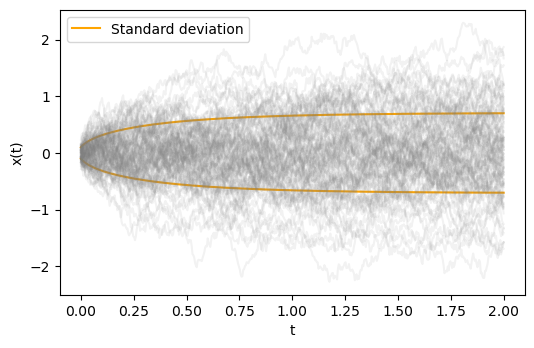

In [3]:
def ou_process(gamma):
    """A discrete approximation of the Ornstein-Uhlenbeck process."""

    green = np.exp(-gamma * t)
    s = gp.cumsum(0.5 * (1/green[1:] + 1/green[:-1]) * w)
    s = x0 + gp.concatenate([[0], s])
    return green * s


x = ou_process(gamma0)

plt.figure(figsize=(6, 3.7))
plt.plot(t, x.std(), color="orange", label="Standard deviation")
plt.plot(t, -x.std(), color="orange")
plt.plot(t, x.sample(100).T, color="gray", alpha=0.1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend();

To find the Fisher information, we can numerically compute the second derivative of $D_\mathrm{KL}$:

In [4]:
alpha = 1e-3

xp = ou_process(gamma0 + alpha)
xm = ou_process(gamma0 - alpha)

fi = (gp.dkl(x, xp) + gp.dkl(x, xm)) / alpha**2

print(f"Fisher information: {fi}")
print(f"Minimum standard deviation for the estimation error of gamma: {1/np.sqrt(fi)}")

Fisher information: 0.759479377165917
Minimum standard deviation for the estimation error of gamma: 1.147471763001216


Because of the normalization property of the probability distribution, the first derivative of $D_\mathrm{KL}$ with respect to $\alpha$ is zero,
\begin{equation*}
\left.\frac{\partial}{\partial\alpha}D_\mathrm{KL}\big(p_\theta(x)||p_{\theta+\alpha}(x)\big)\right|_{\alpha=0}=0,
\end{equation*} 
and $D_\mathrm{KL}$ depends on $\alpha$ only quadratically, so the numeric step in $\alpha$ should not be too small.

In [5]:
(gp.dkl(x, xp) - gp.dkl(x, xm)) / (2 * alpha)  # The first derivative of D_KL is theoretically zero.

-9.947598300641403e-11

# Fit-based estimator

The first estimator of $\gamma$ we construct is simply-minded and works by fitting the theoretical model of the variance of $x$ versus time,
\begin{equation*}
\left\langle x^2(t)\right\rangle = \left\langle x^2_0\right\rangle e^{-2\gamma t} + \frac{1}{2\gamma}\left(1 - e^{-2\gamma t}\right).
\end{equation*}
to the values calculated from the sampled trajectories. (This is probably something I would do if I were to find a rough-and-ready solution to the problem). This estimator may have a little bias, but it is much smaller than the estimation error. 

We set up this estimator as follows:

In [6]:
def var_model(t, x0var, gamma):
    return x0var * np.exp(-2 * t * gamma) + 1 / (2 * gamma) * (1 - np.exp(-2 * t * gamma))


def estimate_var(samples):
    return np.sum(samples**2, axis=0) / len(samples)


def estimate_gamma(samples):
    var_est = estimate_var(samples)
    var_model_ = lambda t, gamma: var_model(t, var_est[0], gamma)
    popt, _ = sp.optimize.curve_fit(var_model_, t, var_est, p0=[2])
    return popt[0]

and then try it on a few trajectories:

Estimated value of gamma: 1.0502594443668194


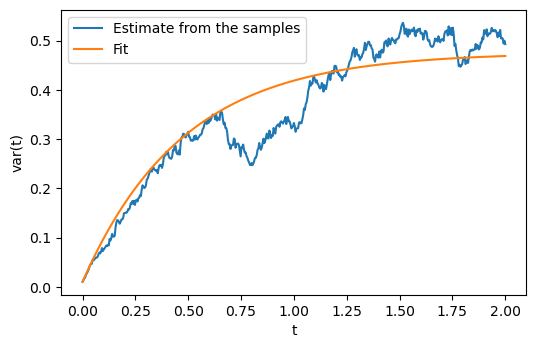

In [7]:
nsamples = 100
samples = x.sample(nsamples)
gamma_e = estimate_gamma(samples)

print(f"Estimated value of gamma: {gamma_e}")

var_e = estimate_var(samples)

plt.figure(figsize=(6, 3.7))
plt.plot(t, var_e, label="Estimate from the samples")
plt.plot(t, var_model(t, var_e[0], gamma_e), label="Fit")
plt.xlabel("t")
plt.ylabel("var(t)")
plt.legend();

 After repeating the estimation experiment several times and comparing the average error to the Cramer-Rao bound, we can conclude that the estimator is fairly efficient, at least for this number of trajectories.

In [8]:
navg = 500

gamma_e = [estimate_gamma(x.sample(nsamples)) for _ in range(navg)]
errsq = [(gamma / gamma0 - 1) ** 2 for gamma in gamma_e]

print(f"RMS estimation error: {np.sqrt(np.mean(errsq))}")
print(f"Cramer-Rao bound: {1 / np.sqrt(fi * nsamples)}")

RMS estimation error: 0.12439227414705
Cramer-Rao bound: 0.1147471763001216


Note that the estimation error obtained above is unrelated to the fitting error of the model of $\left\langle x^2(t)\right\rangle$ to the sampled data. The fitting error is many times smaller than the estimation error.

In [9]:
popt, pcov = sp.optimize.curve_fit(var_model, t, estimate_var(samples), p0=[0, 1])

print(f"The fitting error of gamma in one estimation trial: {np.sqrt(pcov[1, 1])}")
print(f"The ratio of the estimation and fitting RMS errors: {np.sqrt(np.mean(errsq) / pcov[1, 1])}")

The fitting error of gamma in one estimation trial: 0.007839908940973358
The ratio of the estimation and fitting RMS errors: 15.86654578306954


Lastly, we check that the estimator bias is indeed much smaller than the estimation error.

In [10]:
np.mean(gamma_e) - gamma0

0.016665978472052423

# Maximum-likelihood estimator

While there is no general way of constructing an efficient estimator (i.e. one that achieves the Cramer-Rao bound), the maximum-likelihood estimator becomes efficient for large numbers of samples $N$.

For our simple problem, where the process $x(t)$ depends linearly on the parameter $\gamma$, there is an analytical expression for the most-likely value of $\gamma$:
\begin{equation*}
\hat{\gamma} = -\left. \int_0^{T} x(t)\,dx \right/ \int_{0}^{T} x^2(t)\,dt=\lim_{N\to\infty}\left(-\left. \sum_{n=0}^{N-1} x_n\,\Delta x_n \right/ \sum_{n=0}^{N-1} x_n^2\,\Delta t_n\right),
\end{equation*}
The continuous formula above is to be seen as the limit of discrete processes $x_n$ on the time interval $[0,T]$ split into $N$ small steps $\Delta t_n$ with $N\to\infty$. For more details, see section 6.4 in [Kloeden, P. E. & Platen, E. Numerical Solution of Stochastic Differential Equations (1992)](https://doi.org/doi:10.1007/978-3-662-12616-5).


We implement the maximum-likelihood estimator accordingly:

In [11]:
def estimate_gamma_mllk(samples):
    sp = samples[..., 1:]
    sm = samples[..., :-1]
    return -np.sum(sm * (sp - sm)) / (np.sum(sm**2) * dt)

samples = x.sample()

estimate_gamma_mllk(samples)

2.3128546573879993

For the single sample as above, it can be checked via Bayesian analysis that the calculated value is indeed the most likely:

In [12]:
g = gp.normal(0, 1e8)  # A highly-uncertain prior for gamma.
g | {- g * samples[:-1] * dt + w: samples[1:] - samples[:-1]}  # Bayesian estimate of gamma given one trajectory.

Normal(mean=2.3128546, var=2.1809475)

Using the same number of samples as for the fit-based estimator, we can find the average estimation error again, to find that the maximum-likelihood estimator performs marginally better:

In [13]:
gamma_e_mllk = [estimate_gamma_mllk(x.sample(nsamples)) for _ in range(navg)]
errsq_mllk = [(gamma / gamma0 - 1) ** 2 for gamma in gamma_e_mllk]

print(f"RMS estimation error: {np.sqrt(np.mean(errsq_mllk))}")
print(f"Cramer-Rao bound: {1 / np.sqrt(fi * nsamples)}")

RMS estimation error: 0.1147809228470908
Cramer-Rao bound: 0.1147471763001216


# Dependence on the number of trajectories

While for large numbers of samples both the fit-based and the maximum-likelihood estimators come close to the Cramer-Rao bound, for smaller numbers of samples this is less true. We can see this trend below after sweeping the number of samples and plotting the corresponding estimation errors:

In [14]:
er = []
er_mllk = []

nss = [1, 2, 4, 8, 16, 32, 64]

for ns in nss:
    ge = [estimate_gamma(x.sample(ns)) for _ in range(navg)]
    er.append(np.sqrt(np.mean([(gamma / gamma0 - 1) ** 2 for gamma in ge])))

    ge_mllk = [estimate_gamma_mllk(x.sample(ns)) for _ in range(navg)]
    er_mllk.append(np.sqrt(np.mean([(gamma / gamma0 - 1) ** 2 for gamma in ge_mllk])))

# Uncluding the point computed in the previous sections.
nss.append(nsamples)
er.append(np.sqrt(np.mean(errsq)))
er_mllk.append(np.sqrt(np.mean(errsq_mllk)))

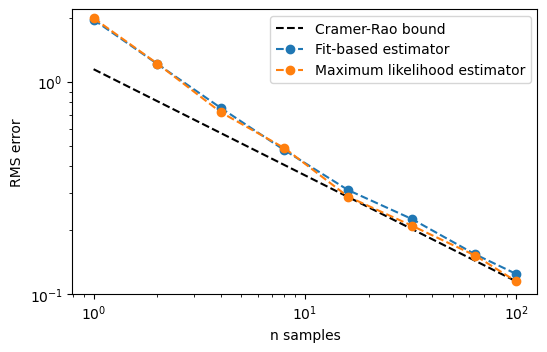

In [15]:
plt.figure(figsize=(6, 3.7))
plt.plot(nss, [1 / np.sqrt(fi * n) for n in nss], "k--", label="Cramer-Rao bound")
plt.plot(nss, er, "--o", label="Fit-based estimator")
plt.plot(nss, er_mllk, "--o", label="Maximum likelihood estimator")
plt.xlabel("n samples")
plt.ylabel("RMS error")
plt.xscale("log")
plt.yscale("log")
plt.ylim(0.1, 2.2)
plt.legend();